# Phân tích khám phá dữ liệu (EDA) cho bộ dữ liệu sách đã làm sạch

## Mục tiêu chính
- Đánh giá tổng quan dữ liệu: kích thước mẫu, cấu trúc bảng, kiểu dữ liệu.
- Đánh giá chất lượng dữ liệu: thiếu dữ liệu, trùng lặp, tính hợp lệ logic.
- Phân tích phân bố các biến chính: định lượng và định tính.
- Phân tích quan hệ giữa các biến để rút ra insight có giá trị thực tiễn.
- Tổng hợp kết luận tự động có thể dùng trực tiếp trong báo cáo.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")


def resolve_project_root(start: Path, markers=("data", "src", "notebooks")) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise RuntimeError(
        "Could not locate PlotTwist project root from the current working directory. "
        "Set MANUAL_PROJECT_ROOT below if your notebook kernel starts outside the project."
    )


MANUAL_PROJECT_ROOT = None
PROJECT_ROOT = Path(MANUAL_PROJECT_ROOT).resolve() if MANUAL_PROJECT_ROOT else resolve_project_root(Path.cwd())

# Try notebook-exported data first, then fallback to legacy processed file.
CANDIDATE_FILES = [
    "book_dataset_clean_notebook.csv",
    "book_dataset_clean_locked_rows_run2.csv",
]

DATA_PATH = None
for file_name in CANDIDATE_FILES:
    candidate_path = PROJECT_ROOT / "data" / "processed" / file_name
    if candidate_path.exists():
        DATA_PATH = candidate_path
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "No processed dataset found. Expected one of: " + ", ".join(CANDIDATE_FILES)
    )

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig", low_memory=False)
if "publication_date" in df.columns:
    df["publication_date"] = pd.to_datetime(df["publication_date"], errors="coerce")
if "publication_year" in df.columns:
    df["publication_year"] = pd.to_numeric(df["publication_year"], errors="coerce")

print(f"Current working directory: {Path.cwd()}")
print(f"Resolved project root: {PROJECT_ROOT}")
print(f"Loaded file: {DATA_PATH}")
print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
display(df.head(5))

Current working directory: c:\Users\ACER\Desktop\Work\Project\DataVis\Lab\PlotTwist\notebooks
Resolved project root: C:\Users\ACER\Desktop\Work\Project\DataVis\Lab\PlotTwist
Loaded file: C:\Users\ACER\Desktop\Work\Project\DataVis\Lab\PlotTwist\data\processed\book_dataset_clean_notebook.csv
Rows: 36,763 | Columns: 30


,id,name,authors,authors_list,primary_author,author_count,price,list_price,discount_rate,rating_average,rating_rate,review_count,all_time_quantity_sold,current_seller_name,current_seller,has_freeship,cat_level_2,cat_level_3,number_of_page,publication_date,publication_year,publisher_vn,manufacturer,isbn13,book_cover,inventory_status,is_authentic,has_return_policy,cat_level_4,cat_level_5
0,26114399,"Sách Nóng Giận Là Bản Năng , Tĩnh Lặng Là Bản ...",Tống Mặc,Tống Mặc,Tống Mặc,1,"83,930.00","109,000.00",23.00,4.80,4.80,"7,257.00","75,282.00",tiki trading,tiki trading,False,sach-truyen-tieng-viet,sach-ky-nang-song,264.00,2019-01-08,2019,Skybooks,Nhà Xuất Bản Thế Giới,NaN,Bìa mềm,available,True,True,sach-ky-nang-song,NaN
1,52789367,Sách Nhà Giả Kim (Tái Bản),Paulo Coelho,Paulo Coelho,Paulo Coelho,1,"78,000.00","95,000.00",18.00,5.00,5.00,"6,076.00","39,825.00",tiki trading,tiki trading,False,sach-truyen-tieng-viet,sach-van-hoc,228.00,2020-04-01,2020,Nhã Nam,Nhà Xuất Bản Hà Nội,NaN,Bìa mềm,available,True,True,tac-pham-kinh-dien,tac-pham-kinh-dien-nuoc-ngoai
2,109017985,"Sách Thiên Tài Bên Trái, Kẻ Điên Bên Phải (Tái...",Cao Minh,Cao Minh,Cao Minh,1,"137,830.00","179,000.00",23.00,4.80,4.80,"5,492.00","27,187.00",tiki trading,tiki trading,False,sach-truyen-tieng-viet,sach-van-hoc,424.00,2021-06-01,2021,Vibooks,Nhà Xuất Bản Thế Giới,NaN,Bìa mềm,available,True,True,truyen-ngan-tan-van-tap-van,truyen-ngan-tan-van-tap-van-nuoc-ngoai
3,278277832,Sách Vui Vẻ Không Quạu Nha - Tản Văn,Ở Đây Zui Nè,Ở Đây Zui Nè,Ở Đây Zui Nè,1,"60,830.00","79,000.00",23.00,4.70,4.70,"5,338.00",13.00,tiki trading,tiki trading,False,sach-truyen-tieng-viet,sach-van-hoc,280.00,2020-03-01,2020,Skybooks,Nhà Xuất Bản Phụ Nữ,NaN,Bìa mềm,available,True,True,truyen-ngan-tan-van-tap-van,truyen-ngan-tan-van-tap-van-viet-nam
4,71345381,Sách Thay Đổi Cuộc Sống Với Nhân Số Học - Lê Đ...,David A. Phillips,David A. Phillips,David A. Phillips,1,"173,462.00","248,000.00",30.00,4.80,4.80,"5,294.00","31,431.00",tiki trading,tiki trading,False,sach-truyen-tieng-viet,sach-ky-nang-song,342.00,2020-10-01,2020,First News - Trí Việt,Nhà Xuất Bản Tổng hợp TP.HCM,NaN,Bìa gập,available,True,True,sach-ky-nang-song,NaN


## 1) Tổng quan dữ liệu và chất lượng dữ liệu

Phần này trả lời trực tiếp yêu cầu bắt buộc của giảng viên, đồng thời mở rộng để đánh giá mức độ sẵn sàng cho phân tích:
- Kích thước mẫu, số biến và dung lượng bộ nhớ.
- Cấu trúc cột, kiểu dữ liệu, mức độ thiếu dữ liệu.
- Trùng lặp theo khóa và trùng lặp toàn dòng.
- Bức tranh tổng quát về missing theo từng cột.

,metric,value
0,rows,"36,763.00"
1,columns,30.00
2,memory_mb,49.01


,column,dtype,non_null_count,missing_count,unique_count,missing_rate_%,unique_rate_%
23,isbn13,object,2011,34752,1902,94.53,5.17
29,cat_level_5,object,12716,24047,175,65.41,0.48
22,manufacturer,object,33834,2929,400,7.97,1.09
24,book_cover,object,36026,737,33,2.00,0.09
28,cat_level_4,object,36138,625,186,1.70,0.51
21,publisher_vn,object,36756,7,844,0.02,2.30
0,id,int64,36763,0,36763,0.00,100.00
1,name,object,36763,0,35776,0.00,97.31
2,authors,object,36763,0,13747,0.00,37.39
3,authors_list,object,36763,0,13647,0.00,37.12


,dtype,column_count,total_missing
0,object,15,63097
1,float64,8,0
2,bool,3,0
3,int64,3,0
4,datetime64[ns],1,0


,metric,value
0,duplicate_id_rows,0.00
1,duplicate_full_rows,0.00
2,missing_cells_total,"63,097.00"
3,missing_ratio_total_%,5.72


,missing_count,missing_rate_%
isbn13,34752,94.53
cat_level_5,24047,65.41
manufacturer,2929,7.97
book_cover,737,2.00
cat_level_4,625,1.70
publisher_vn,7,0.02
price,0,0.00
list_price,0,0.00
id,0,0.00
name,0,0.00


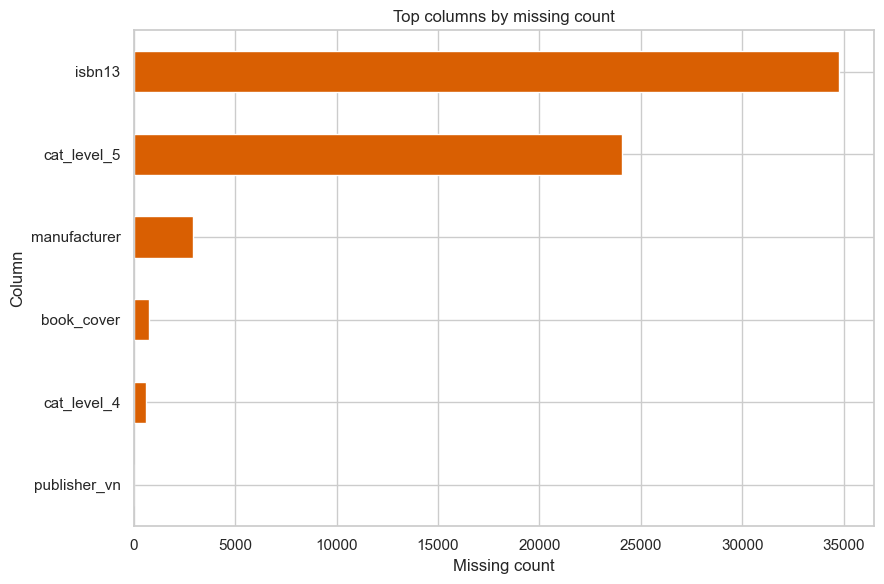

In [2]:
# High-level dataset overview.
overview = pd.DataFrame(
    {
        "metric": ["rows", "columns", "memory_mb"],
        "value": [
            len(df),
            df.shape[1],
            round(df.memory_usage(deep=True).sum() / 1024**2, 3),
        ],
    }
)
display(overview)

# Column-level schema profile.
schema_profile = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "non_null_count": df.notna().sum().values,
        "missing_count": df.isna().sum().values,
        "unique_count": [df[c].nunique(dropna=True) for c in df.columns],
    }
)
schema_profile["missing_rate_%"] = (schema_profile["missing_count"] / len(df) * 100).round(3)
schema_profile["unique_rate_%"] = (schema_profile["unique_count"] / len(df) * 100).round(3)

display(schema_profile.sort_values(["missing_count", "unique_count", "column"], ascending=[False, False, True]))

dtype_summary = (
    schema_profile.groupby("dtype", as_index=False)
    .agg(column_count=("column", "count"), total_missing=("missing_count", "sum"))
    .sort_values("column_count", ascending=False)
    .reset_index(drop=True)
)
display(dtype_summary)

# Duplicate and missing-data headline.
duplicate_id = int(df.duplicated(subset=["id"]).sum()) if "id" in df.columns else np.nan
duplicate_full = int(df.duplicated().sum())
missing_cells = int(df.isna().sum().sum())
total_cells = int(df.shape[0] * df.shape[1])
missing_ratio = (missing_cells / total_cells * 100) if total_cells else np.nan

quality_headline = pd.DataFrame(
    {
        "metric": [
            "duplicate_id_rows",
            "duplicate_full_rows",
            "missing_cells_total",
            "missing_ratio_total_%",
        ],
        "value": [duplicate_id, duplicate_full, missing_cells, round(missing_ratio, 4)],
    }
)
display(quality_headline)

missing_by_col = df.isna().sum().sort_values(ascending=False).to_frame("missing_count")
missing_by_col["missing_rate_%"] = (missing_by_col["missing_count"] / len(df) * 100).round(3)
display(missing_by_col.head(25))

non_zero_missing = missing_by_col[missing_by_col["missing_count"] > 0]
if non_zero_missing.empty:
    print("No missing values detected in this processed dataset.")
else:
    ax = non_zero_missing.head(20).sort_values("missing_count").plot(
        kind="barh",
        y="missing_count",
        legend=False,
        figsize=(9, 6),
        color="#d95f02",
    )
    ax.set_title("Top columns by missing count")
    ax.set_xlabel("Missing count")
    ax.set_ylabel("Column")
    plt.tight_layout()
    plt.show()

## 2) Phân tích biến Numerical
Phần này đi sâu vào các biến numerical để trả lời:
- Mức trung tâm và độ phân tán của từng biến.
- Mức độ lệch phân phối.
- Tỷ lệ ngoại lệ theo quy tắc IQR.
- Ảnh hưởng của đuôi dài lên biểu đồ.

In [3]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")

if numeric_cols:
    desc = df[numeric_cols].describe(
        percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
    ).T
    desc["iqr"] = desc["75%"] - desc["25%"]
    desc["cv"] = np.where(desc["mean"].abs() > 0, desc["std"] / desc["mean"].abs(), np.nan)
    desc["skew"] = df[numeric_cols].skew(numeric_only=True)
    desc["kurtosis"] = df[numeric_cols].kurtosis(numeric_only=True)
    display(desc.sort_values("std", ascending=False))

    def iqr_outlier_stats(series: pd.Series) -> tuple[int, float, float, float]:
        s = series.dropna()
        if s.empty:
            return 0, 0.0, np.nan, np.nan
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        if iqr == 0:
            return 0, 0.0, np.nan, np.nan
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_count = int(((s < lower) | (s > upper)).sum())
        outlier_rate = outlier_count / len(s) * 100
        return outlier_count, outlier_rate, lower, upper

    outlier_table = []
    for col in numeric_cols:
        outlier_count, outlier_rate, lower_bound, upper_bound = iqr_outlier_stats(df[col])
        outlier_table.append(
            {
                "column": col,
                "outlier_count": outlier_count,
                "outlier_rate_%": round(outlier_rate, 3),
                "lower_bound": lower_bound,
                "upper_bound": upper_bound,
            }
        )

    outlier_df = pd.DataFrame(outlier_table).sort_values(
        "outlier_rate_%", ascending=False
    )
    display(outlier_df)
else:
    print("No numeric columns found.")

Numeric columns (11): ['id', 'author_count', 'price', 'list_price', 'discount_rate', 'rating_average', 'rating_rate', 'review_count', 'all_time_quantity_sold', 'number_of_page', 'publication_year']


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,iqr,cv,skew,kurtosis
id,"36,763.00","175,164,392.40","110,228,386.82","313,607.00","366,554.44","491,341.50","57,176,838.00","212,356,656.00","275,782,189.50","278,811,866.90","279,189,428.76","279,314,863.00","218,605,351.50",0.63,-0.54,-1.39
list_price,"36,763.00","175,804.93","166,771.40","5,460.00","20,000.00","38,000.00","88,000.00","139,000.00","207,500.00","435,000.00","803,760.00","5,200,000.00","119,500.00",0.95,6.00,82.08
price,"36,763.00","158,214.00","158,527.08",0.00,"18,000.00","32,800.00","75,900.00","120,000.00","189,000.00","390,000.00","768,364.80","5,200,000.00","113,100.00",1.00,6.54,98.00
all_time_quantity_sold,"36,763.00",152.29,"1,236.72",0.00,0.00,0.00,0.00,4.00,40.00,445.00,"2,630.80","75,282.00",40.00,8.12,27.24,"1,045.77"
number_of_page,"36,763.00",311.99,258.73,1.00,16.00,32.00,172.00,272.00,392.00,687.00,"1,300.00","5,000.00",220.00,0.83,4.29,38.88
review_count,"36,763.00",17.91,146.73,0.00,0.00,0.00,0.00,0.00,3.00,51.00,323.38,"7,257.00",3.00,8.19,23.05,706.44
discount_rate,"36,763.00",10.56,12.66,0.00,0.00,0.00,0.00,5.00,20.00,34.00,43.00,100.00,20.00,1.20,0.91,-0.19
publication_year,"36,763.00","2,020.74",6.27,"1,900.00","2,007.00","2,014.00","2,019.00","2,022.00","2,023.00","2,025.00","2,026.00","2,103.00",4.00,0.00,-12.14,223.68
rating_rate,"36,763.00",2.04,2.39,0.00,0.00,0.00,0.00,0.00,5.00,5.00,5.00,5.00,5.00,1.17,0.34,-1.86
rating_average,"36,763.00",2.04,2.39,0.00,0.00,0.00,0.00,0.00,5.00,5.00,5.00,5.00,5.00,1.17,0.34,-1.86


,column,outlier_count,outlier_rate_%,lower_bound,upper_bound
7,review_count,6255,17.01,-4.50,7.50
8,all_time_quantity_sold,5602,15.24,-60.00,100.00
2,price,2322,6.32,"-93,750.00","358,650.00"
3,list_price,2318,6.30,"-91,250.00","386,750.00"
9,number_of_page,1572,4.28,-158.00,722.00
10,publication_year,1293,3.52,"2,013.00","2,029.00"
4,discount_rate,56,0.15,-30.00,50.00
1,author_count,0,0.00,NaN,NaN
0,id,0,0.00,"-270,731,189.25","603,690,216.75"
6,rating_rate,0,0.00,-7.50,12.50


d:\Anaconda\envs\torch-gpu\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
d:\Anaconda\envs\torch-gpu\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
d:\Anaconda\envs\torch-gpu\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
d:\Anaconda\envs\torch-gpu\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
d:\Anaconda\envs\torch-gpu\Lib\site-pack

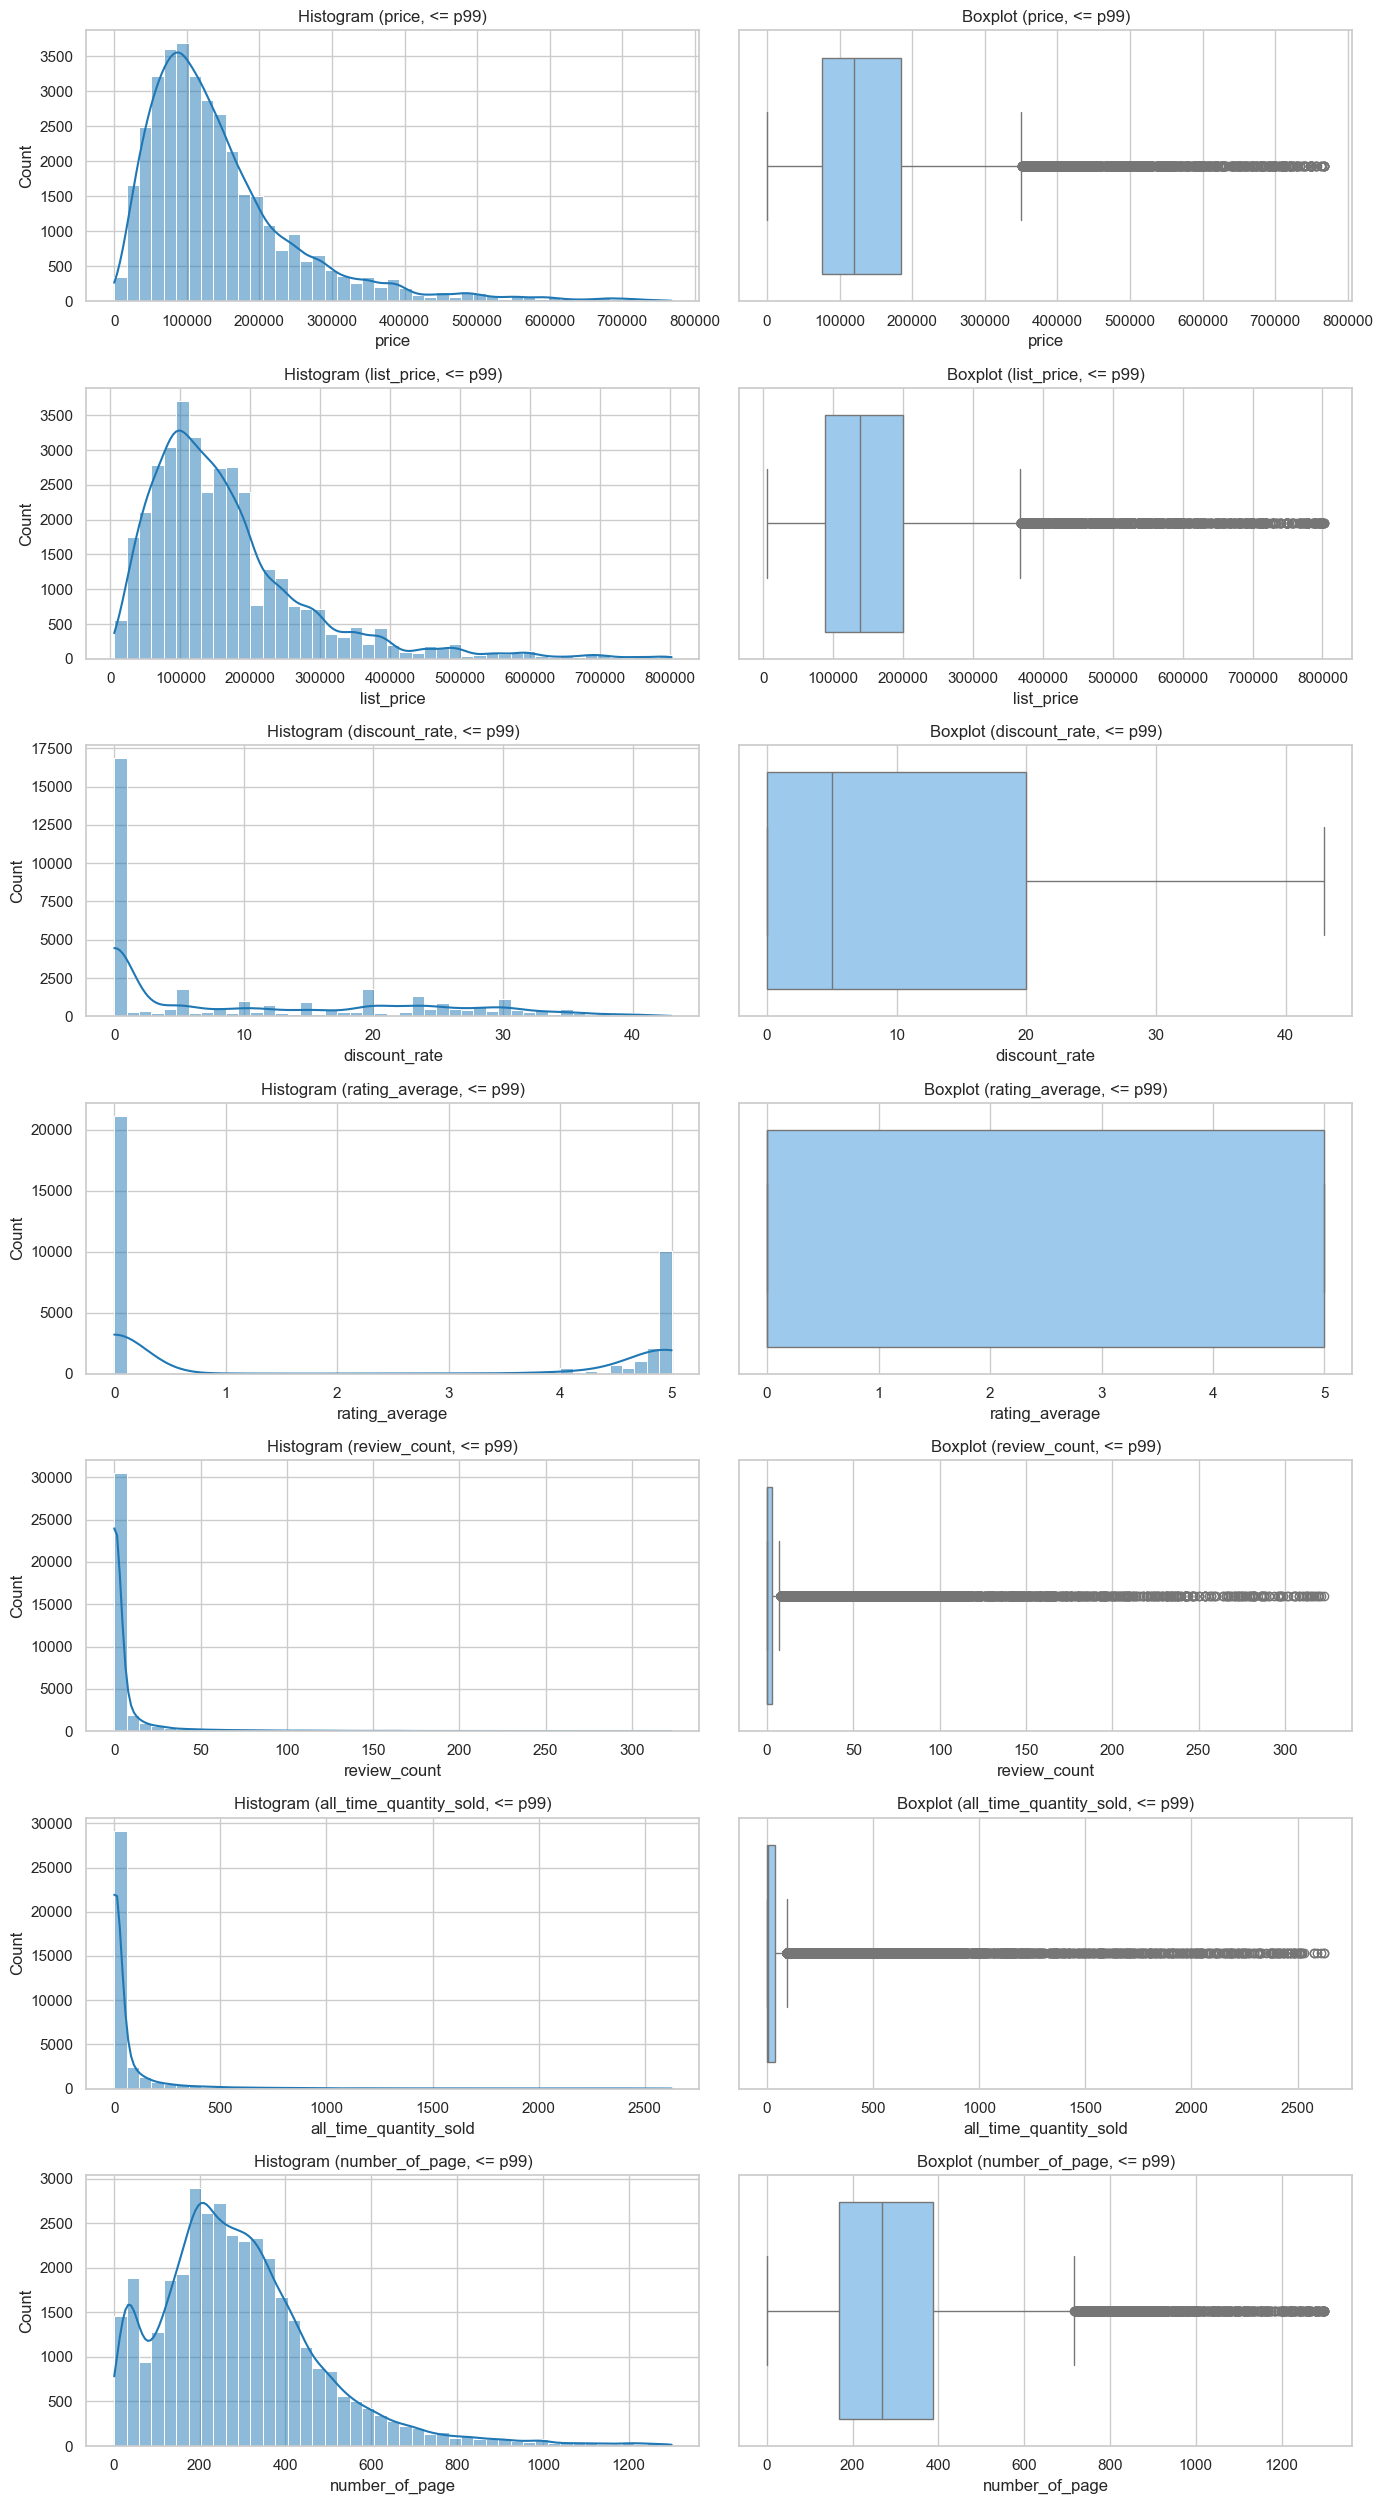

In [4]:
plot_candidates = [
    "price",
    "list_price",
    "discount_rate",
    "rating_average",
    "review_count",
    "all_time_quantity_sold",
    "number_of_page",
    "stock",
]
plot_numeric = [c for c in plot_candidates if c in df.columns]

if not plot_numeric:
    plot_numeric = numeric_cols[:8]

if plot_numeric:
    fig, axes = plt.subplots(len(plot_numeric), 2, figsize=(14, 3.6 * len(plot_numeric)))
    axes = np.array(axes).reshape(len(plot_numeric), 2)

    for row_idx, col in enumerate(plot_numeric):
        series = df[col].dropna()
        left_ax, right_ax = axes[row_idx]

        if series.empty:
            left_ax.set_title(f"{col}: no data")
            left_ax.axis("off")
            right_ax.axis("off")
            continue

        p99 = series.quantile(0.99)
        clipped = series[series <= p99]
        if clipped.empty:
            clipped = series

        sns.histplot(clipped, bins=45, kde=True, ax=left_ax, color="#1f77b4")
        left_ax.set_title(f"Histogram ({col}, <= p99)")
        left_ax.set_xlabel(col)

        sns.boxplot(x=clipped, ax=right_ax, color="#90caf9")
        right_ax.set_title(f"Boxplot ({col}, <= p99)")
        right_ax.set_xlabel(col)

    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns available for plotting.")

## 3) Cấu trúc biến Categorical

Mục tiêu của phần này:
- Đo mức độ đa dạng của các biến Categorical.
- Xác định nhóm chính theo tần suất (top danh mục, nhà bán, nhà xuất bản, tác giả).
- Quan sát mức độ tập trung để quyết định cách hiển thị trong dashboard (top-N, long-tail, gom nhóm).

In [5]:
categorical_cols = df.select_dtypes(include=["object", "string", "category", "boolean"]).columns.tolist()
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

def compute_top1_share(series: pd.Series) -> float:
    s = series.fillna("<NA>").astype("string")
    if len(s) == 0:
        return 0.0
    return round(float(s.value_counts(normalize=True, dropna=False).iloc[0] * 100), 3)

cat_profile = pd.DataFrame(
    {
        "column": categorical_cols,
        "unique_values": [df[c].nunique(dropna=True) for c in categorical_cols],
        "missing_rate_%": [round(df[c].isna().mean() * 100, 3) for c in categorical_cols],
        "top1_share_%": [compute_top1_share(df[c]) for c in categorical_cols],
    }
).sort_values(["unique_values", "top1_share_%"], ascending=[False, False])

display(cat_profile)


def top_counts(dataframe: pd.DataFrame, col: str, top_n: int = 15) -> pd.DataFrame:
    vc = dataframe[col].fillna("<NA>").astype("string").value_counts().head(top_n)
    out = vc.rename_axis(col).reset_index(name="count")
    out["share_%"] = (out["count"] / len(dataframe) * 100).round(3)
    return out


for col in ["cat_level_2", "cat_level_3", "publisher_vn", "current_seller_name", "primary_author"]:
    if col in df.columns:
        print(f"Top values for: {col}")
        display(top_counts(df, col, top_n=15))

Categorical columns (18): ['name', 'authors', 'authors_list', 'primary_author', 'current_seller_name', 'current_seller', 'has_freeship', 'cat_level_2', 'cat_level_3', 'publisher_vn', 'manufacturer', 'isbn13', 'book_cover', 'inventory_status', 'is_authentic', 'has_return_policy', 'cat_level_4', 'cat_level_5']


,column,unique_values,missing_rate_%,top1_share_%
0,name,35776,0.00,0.02
1,authors,13747,0.00,4.25
2,authors_list,13647,0.00,4.25
3,primary_author,12479,0.00,4.28
11,isbn13,1902,94.53,94.53
9,publisher_vn,844,0.02,7.97
10,manufacturer,400,7.97,8.08
4,current_seller_name,326,0.00,26.89
5,current_seller,326,0.00,26.89
16,cat_level_4,186,1.70,4.15


Top values for: cat_level_2


,cat_level_2,count,share_%
0,sach-truyen-tieng-viet,34731,94.47
1,sach-tieng-anh,2032,5.53


Top values for: cat_level_3


...

,publisher_vn,count,share_%
0,Nhã Nam,2932,7.97
1,NXB Trẻ,2808,7.64
2,Alphabooks,2060,5.60
3,Thái Hà,1480,4.03
4,1980 Books,990,2.69
5,NXB Kim Đồng,931,2.53
6,First News - Trí Việt,883,2.40
7,Nhà Xuất Bản Kim Đồng,825,2.24
8,Nhân Trí Việt,732,1.99
9,Alpha Books,723,1.97


Top values for: current_seller_name


,current_seller_name,count,share_%
0,tiki trading,9886,26.89
1,nhà sách fahasa,3428,9.32
2,bamboo books,2385,6.49
3,nhà sách netabooks,1679,4.57
4,nhà sách vĩnh thụy,1665,4.53
5,bookworm hà nội,1131,3.08
6,hệ thống nhà sách abc,989,2.69
7,bảo châu books,963,2.62
8,info book,931,2.53
9,alpha books official,892,2.43


Top values for: primary_author


,primary_author,count,share_%
0,nhieu tac gia,1572,4.28
1,Nhiều tác giả,980,2.67
2,.,589,1.60
3,Many Authors,306,0.83
4,Nguyễn Nhật Ánh,288,0.78
5,Thích Nhất Hạnh,130,0.35
6,Agatha Christie,129,0.35
7,Osho,119,0.32
8,DK,114,0.31
9,Mai Lan Hương,113,0.31


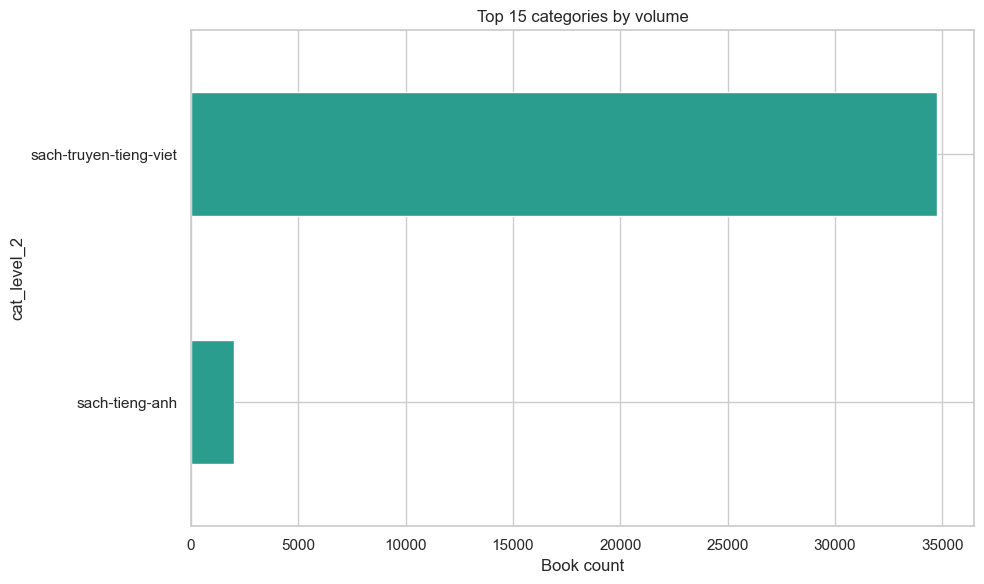

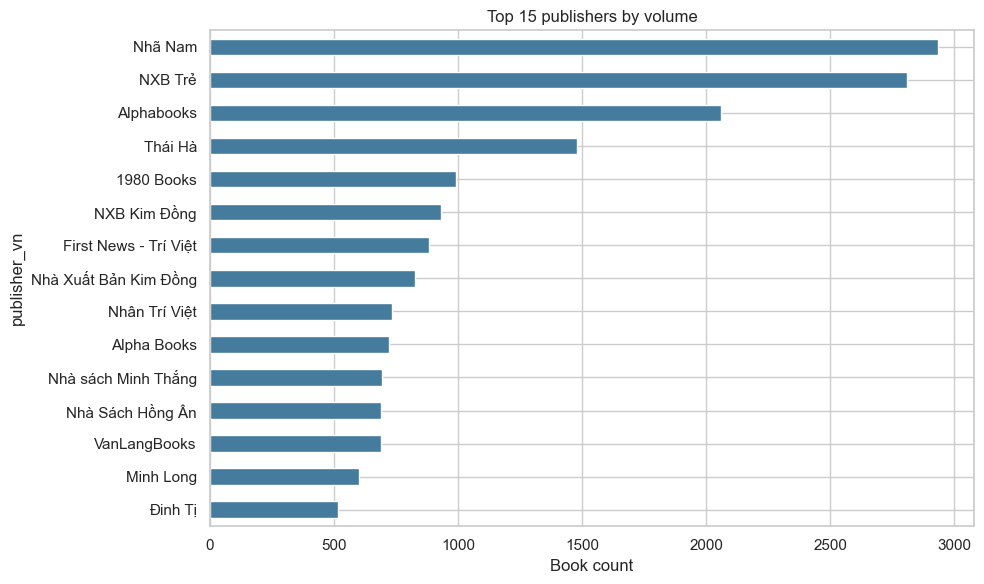

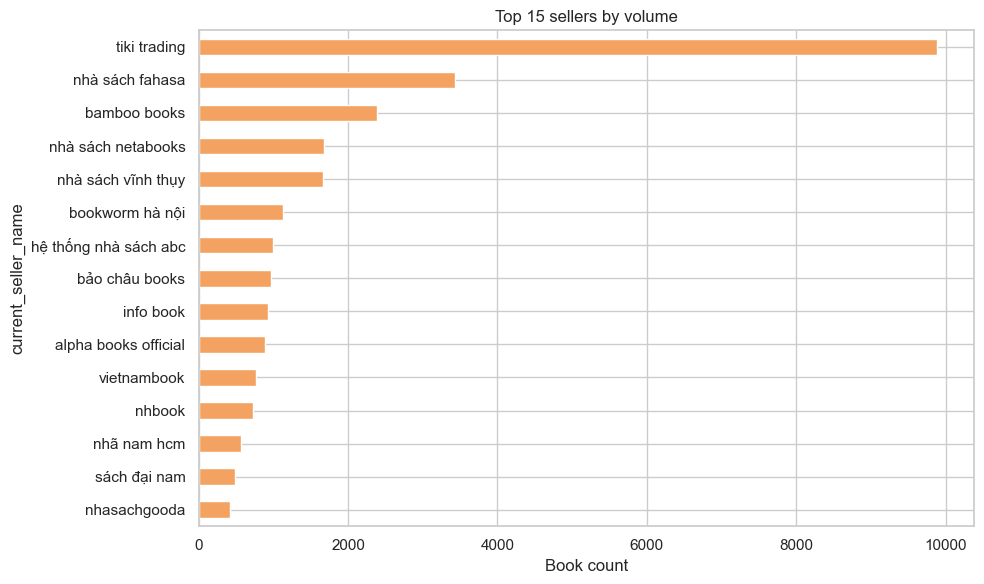

In [6]:
def plot_top_barh(dataframe: pd.DataFrame, column: str, top_n: int, color: str, title: str) -> None:
    top_series = dataframe[column].fillna("<NA>").astype("string").value_counts().head(top_n).sort_values()
    if top_series.empty:
        return
    plt.figure(figsize=(10, 6))
    top_series.plot(kind="barh", color=color)
    plt.title(title)
    plt.xlabel("Book count")
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

if "cat_level_2" in df.columns:
    plot_top_barh(df, "cat_level_2", top_n=15, color="#2a9d8f", title="Top 15 categories by volume")

if "publisher_vn" in df.columns:
    plot_top_barh(df, "publisher_vn", top_n=15, color="#457b9d", title="Top 15 publishers by volume")

if "current_seller_name" in df.columns:
    plot_top_barh(df, "current_seller_name", top_n=15, color="#f4a261", title="Top 15 sellers by volume")

## 4) Phân tích quan hệ giữa các biến chính

Phần này tập trung vào các câu hỏi có giá trị thực tiễn:
- Giá và mức giảm giá có liên hệ như thế nào với doanh số?
- Rating và review có phản ánh sức bán hay không?
- Biến nào đồng biến/nghịch biến rõ rệt trong ma trận tương quan?
- Mức tương quan thay đổi ra sao giữa Pearson và Spearman?

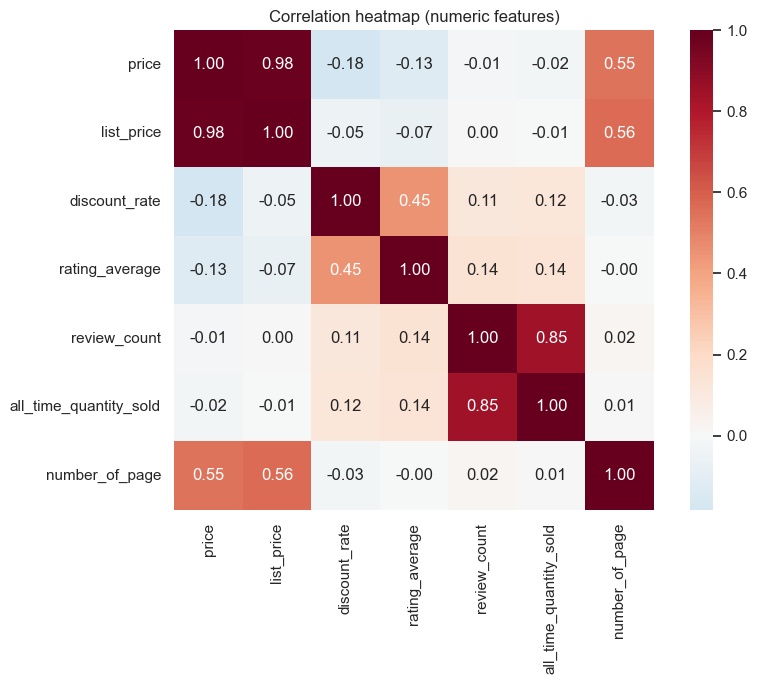

,pair,n,pearson,spearman
0,price vs all_time_quantity_sold,36763,-0.02,-0.24
1,discount_rate vs all_time_quantity_sold,36763,0.12,0.60
2,rating_average vs review_count,36763,0.14,0.90
3,review_count vs all_time_quantity_sold,36763,0.85,0.86


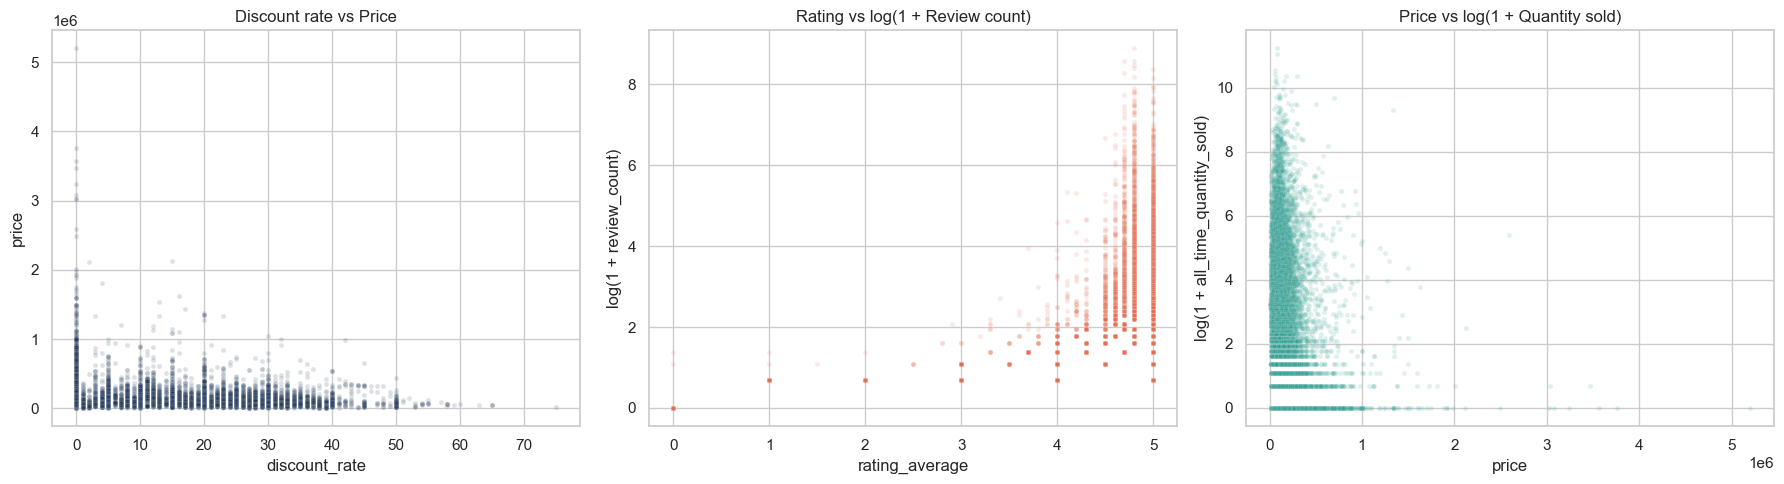

In [7]:
corr_candidates = [
    "price",
    "list_price",
    "discount_rate",
    "rating_average",
    "review_count",
    "all_time_quantity_sold",
    "stock",
    "number_of_page",
]
corr_cols = [c for c in corr_candidates if c in df.columns]

if len(corr_cols) >= 2:
    corr = df[corr_cols].corr(numeric_only=True)
    plt.figure(figsize=(9, 7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
    plt.title("Correlation heatmap (numeric features)")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for correlation analysis.")

pair_candidates = [
    ("price", "all_time_quantity_sold"),
    ("discount_rate", "all_time_quantity_sold"),
    ("rating_average", "review_count"),
    ("review_count", "all_time_quantity_sold"),
]

pair_stats = []
for x_col, y_col in pair_candidates:
    if {x_col, y_col}.issubset(df.columns):
        subset = df[[x_col, y_col]].dropna()
        if len(subset) >= 3:
            pair_stats.append(
                {
                    "pair": f"{x_col} vs {y_col}",
                    "n": int(len(subset)),
                    "pearson": round(float(subset[x_col].corr(subset[y_col], method="pearson")), 4),
                    "spearman": round(float(subset[x_col].corr(subset[y_col], method="spearman")), 4),
                }
            )

if pair_stats:
    display(pd.DataFrame(pair_stats))

sample = df.sample(n=min(20000, len(df)), random_state=42).copy()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if {"discount_rate", "price"}.issubset(sample.columns) and len(sample) > 0:
    sns.scatterplot(
        data=sample,
        x="discount_rate",
        y="price",
        alpha=0.15,
        s=12,
        ax=axes[0],
        color="#1d3557",
    )
    axes[0].set_title("Discount rate vs Price")
else:
    axes[0].set_axis_off()

if {"rating_average", "review_count"}.issubset(sample.columns) and len(sample) > 0:
    sample["review_count_log1p"] = np.log1p(sample["review_count"] )
    sns.scatterplot(
        data=sample,
        x="rating_average",
        y="review_count_log1p",
        alpha=0.15,
        s=12,
        ax=axes[1],
        color="#e76f51",
    )
    axes[1].set_title("Rating vs log(1 + Review count)")
    axes[1].set_ylabel("log(1 + review_count)")
else:
    axes[1].set_axis_off()

if {"price", "all_time_quantity_sold"}.issubset(sample.columns) and len(sample) > 0:
    sample["sold_log1p"] = np.log1p(sample["all_time_quantity_sold"] )
    sns.scatterplot(
        data=sample,
        x="price",
        y="sold_log1p",
        alpha=0.15,
        s=12,
        ax=axes[2],
        color="#2a9d8f",
    )
    axes[2].set_title("Price vs log(1 + Quantity sold)")
    axes[2].set_ylabel("log(1 + all_time_quantity_sold)")
else:
    axes[2].set_axis_off()

plt.tight_layout()
plt.show()

## 5) Kết luận EDA trọng tâm

In [9]:
insights = {}

if "cat_level_2" in df.columns:
    top_cat2_name = df["cat_level_2"].fillna("<NA>").value_counts().index[0]
    top_cat2_count = int(df["cat_level_2"].fillna("<NA>").value_counts().iloc[0])
    insights["top_cat_level_2"] = f"{top_cat2_name} ({top_cat2_count:,} books)"

if "publisher_vn" in df.columns:
    top_publisher = df["publisher_vn"].fillna("<NA>").value_counts().index[0]
    top_publisher_count = int(df["publisher_vn"].fillna("<NA>").value_counts().iloc[0])
    insights["top_publisher"] = f"{top_publisher} ({top_publisher_count:,} books)"

if "current_seller_name" in df.columns:
    top_seller = df["current_seller_name"].fillna("<NA>").value_counts().index[0]
    top_seller_count = int(df["current_seller_name"].fillna("<NA>").value_counts().iloc[0])
    insights["top_seller"] = f"{top_seller} ({top_seller_count:,} books)"

if "discount_rate" in df.columns:
    insights["median_discount_rate"] = float(df["discount_rate"].median())

if "price" in df.columns:
    insights["median_price"] = float(df["price"].median())

if "rating_average" in df.columns:
    insights["median_rating"] = float(df["rating_average"].median())

if "review_count" in df.columns:
    insights["median_review_count"] = float(df["review_count"].median())

if "all_time_quantity_sold" in df.columns:
    insights["median_quantity_sold"] = float(df["all_time_quantity_sold"].median())

print("EDA summary insights:")
for k, v in insights.items():
    print(f"- {k}: {v}")

insights

EDA summary insights:
- top_cat_level_2: sach-truyen-tieng-viet (34,731 books)
- top_publisher: Nhã Nam (2,932 books)
- top_seller: tiki trading (9,886 books)
- median_discount_rate: 5.0
- median_price: 120000.0
- median_rating: 0.0
- median_review_count: 0.0
- median_quantity_sold: 4.0


{'top_cat_level_2': 'sach-truyen-tieng-viet (34,731 books)',
 'top_publisher': 'Nhã Nam (2,932 books)',
 'top_seller': 'tiki trading (9,886 books)',
 'median_discount_rate': 5.0,
 'median_price': 120000.0,
 'median_rating': 0.0,
 'median_review_count': 0.0,
 'median_quantity_sold': 4.0}